In [31]:
import os
from openai import OpenAI
from os import environ
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.embeddings.openai import OpenAIEmbeddings
from langchain.vectorstores import Chroma
from langchain.schema import Document
from langchain_openai import ChatOpenAI

# Ensure the OpenAI API key is available for langchain wrappers
environ['OPENAI_API_KEY'] = os.environ.get('API_KEY', '')

# Create an LLM wrapper for LangChain flows (used by generate())
llm = ChatOpenAI(model="openai.gpt-4o", temperature=0.2)

In [32]:
client = OpenAI(
	api_key=os.environ["API_KEY"],
	base_url="https://api.ai.it.cornell.edu",
)

In [8]:
# Streamlit UI
# the streamlight doc uploader goes here in the regular python file

In [33]:
from langchain_community.document_loaders import TextLoader
loader = TextLoader("/workspaces/INFO-5940-Codespace/data/fishing.txt")
documents = loader.load()

In [34]:
print(documents[0].page_content)

The Meditative Art of Fly-Fishing: An In-Depth Examination
Fly-fishing is often described, rightly, as more than a sport; it is an amalgamation of art, science, and philosophy. It demands the participant engage with nature on multiple, intimate levels—from the micro-ecology of aquatic insects to the fluid dynamics of a meandering stream. It is a pursuit steeped in tradition, yet constantly evolving, challenging both the body and the mind in equal measure. Unlike bait fishing or spin casting, where the weight of the lure carries the line, fly-fishing utilizes the weight and mass of a specially designed line to propel a nearly weightless imitation of an insect or baitfish. This fundamental distinction defines the elegance and complexity that elevates fly-fishing to a contemplative practice, a true communion with the wild.
The history of fly-fishing stretches back to antiquity, illustrating its profound cultural roots. The earliest known reference dates to the Roman writer Claudius Aelian

In [35]:
# Split the text into chunks for RAG
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=200,  # Set chunk size to divide the text
    chunk_overlap=0  # Set overlap size between chunks (optional)
    )

In [36]:
chunks = text_splitter.split_documents(documents)

In [37]:
# Test the text splitter
for chunk in chunks:
    print(chunk.page_content)
    print("~~~~")

The Meditative Art of Fly-Fishing: An In-Depth Examination
~~~~
Fly-fishing is often described, rightly, as more than a sport; it is an amalgamation of art, science, and philosophy. It demands the participant engage with nature on multiple, intimate levels—from
~~~~
the micro-ecology of aquatic insects to the fluid dynamics of a meandering stream. It is a pursuit steeped in tradition, yet constantly evolving, challenging both the body and the mind in equal
~~~~
measure. Unlike bait fishing or spin casting, where the weight of the lure carries the line, fly-fishing utilizes the weight and mass of a specially designed line to propel a nearly weightless
~~~~
imitation of an insect or baitfish. This fundamental distinction defines the elegance and complexity that elevates fly-fishing to a contemplative practice, a true communion with the wild.
~~~~
The history of fly-fishing stretches back to antiquity, illustrating its profound cultural roots. The earliest known reference dates to the Rom

In [38]:
# Create embeddings + vectorstore and retriever (run AFTER the cell that defines `chunks`)
from langchain_openai import OpenAIEmbeddings
from langchain.vectorstores import Chroma


In [39]:
 # Store the chunks in a vector store
vectorstore = Chroma.from_documents(
    documents=chunks, 
    embedding=OpenAIEmbeddings(model="openai.text-embedding-3-large")
            )

In [40]:
vectorstore.similarity_search("How often should I go fishing?")

[Document(metadata={'source': '/workspaces/INFO-5940-Codespace/data/fishing.txt'}, page_content='ethical codes of fishing—emphasizing conservation and the spiritual value of the pursuit—but also practical advice on tackle construction, including recipes for twelve specific artificial flies. It'),
 Document(metadata={'source': '/workspaces/INFO-5940-Codespace/data/fishing.txt'}, page_content='ethical codes of fishing—emphasizing conservation and the spiritual value of the pursuit—but also practical advice on tackle construction, including recipes for twelve specific artificial flies. It'),
 Document(metadata={'source': '/workspaces/INFO-5940-Codespace/data/fishing.txt'}, page_content="the angler's objective and the environment."),
 Document(metadata={'source': '/workspaces/INFO-5940-Codespace/data/fishing.txt'}, page_content="the angler's objective and the environment.")]

In [41]:
vectorstore.similarity_search_with_relevance_scores("How often shoud I go fishing?")

[(Document(metadata={'source': '/workspaces/INFO-5940-Codespace/data/fishing.txt'}, page_content="the angler's objective and the environment."),
  0.15612180636117412),
 (Document(metadata={'source': '/workspaces/INFO-5940-Codespace/data/fishing.txt'}, page_content="the angler's objective and the environment."),
  0.15608851035085058),
 (Document(metadata={'source': '/workspaces/INFO-5940-Codespace/data/fishing.txt'}, page_content='ethical codes of fishing—emphasizing conservation and the spiritual value of the pursuit—but also practical advice on tackle construction, including recipes for twelve specific artificial flies. It'),
  0.14237367296431458),
 (Document(metadata={'source': '/workspaces/INFO-5940-Codespace/data/fishing.txt'}, page_content='ethical codes of fishing—emphasizing conservation and the spiritual value of the pursuit—but also practical advice on tackle construction, including recipes for twelve specific artificial flies. It'),
  0.14229325677735571)]

In [42]:
  # Retreive relevant chunks from the vector store
  retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 20})
 
  def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

In [43]:
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

In [44]:
format_docs(retriever.invoke("How often should I go fishing?"))

"ethical codes of fishing—emphasizing conservation and the spiritual value of the pursuit—but also practical advice on tackle construction, including recipes for twelve specific artificial flies. It\n\nethical codes of fishing—emphasizing conservation and the spiritual value of the pursuit—but also practical advice on tackle construction, including recipes for twelve specific artificial flies. It\n\nthe angler's objective and the environment.\n\nthe angler's objective and the environment.\n\nThe Meditative Art of Fly-Fishing: An In-Depth Examination\n\nThe Meditative Art of Fly-Fishing: An In-Depth Examination\n\nrate low, and the learning curve endless. This pursuit of perfection, knowing it will never be fully attained, instills a unique brand of patience. When casting, the angler must clear their mind,\n\nrate low, and the learning curve endless. This pursuit of perfection, knowing it will never be fully attained, instills a unique brand of patience. When casting, the angler must cl

In [45]:
from langchain_core.prompts import PromptTemplate

template = """
    You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. 
    If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
    
    Question: {question}
    
    Context: {context} 
    
    Answer:
"""
prompt = PromptTemplate.from_template(template)

In [46]:
from langchain_core.documents import Document
from typing_extensions import List, TypedDict


class State(TypedDict):
    question: str
    context: List[Document]
    answer: str

In [47]:
def retrieve(state: State):
    retrieved_docs = vectorstore.similarity_search(state["question"], k=20)
    return {"context": retrieved_docs}


def generate(state: State):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt.invoke({"question": state["question"], "context": docs_content})
    response = llm.invoke(messages)
    return {"answer": response.content}

In [48]:
from langgraph.graph import START, StateGraph

graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

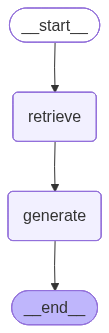

In [49]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [50]:
result = graph.invoke({"question": "What is fly fishing?"})

print(f"Context: {result['context']}\n\n")
print(f"Answer: {result['answer']}")

Context: [Document(metadata={'source': '/workspaces/INFO-5940-Codespace/data/fishing.txt'}, page_content='imitation of an insect or baitfish. This fundamental distinction defines the elegance and complexity that elevates fly-fishing to a contemplative practice, a true communion with the wild.'), Document(metadata={'source': '/workspaces/INFO-5940-Codespace/data/fishing.txt'}, page_content='imitation of an insect or baitfish. This fundamental distinction defines the elegance and complexity that elevates fly-fishing to a contemplative practice, a true communion with the wild.'), Document(metadata={'source': '/workspaces/INFO-5940-Codespace/data/fishing.txt'}, page_content="The equipment of fly-fishing is an intricate system, each component playing a vital role in transmitting the cast's energy and presenting the fly convincingly. At the heart of the system is the fly"), Document(metadata={'source': '/workspaces/INFO-5940-Codespace/data/fishing.txt'}, page_content="The equipment of fly-fi